# Hydrogel Drug Release and Efficacy Prediction

This notebook builds machine learning models to predict:
1. **Drug Release at 48 hours** (mg/ml)
2. **Efficacy Score** (0-1 normalized)

based on polymer formulation parameters.

## 1. Import Libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Generate Synthetic Dataset

In [62]:
# Number of samples
n_samples = 500

# Random seed for reproducibility
np.random.seed(42)

# Features
polymer_types = ['PEG', 'Gelatin', 'Chitosan']
polymer_type = np.random.choice(polymer_types, size=n_samples)
polymer_concentration = np.random.uniform(0.5, 10.0, size=n_samples)  # %
crosslink_density = np.random.uniform(0.1, 1.0, size=n_samples)
temperature = np.random.uniform(20, 40, size=n_samples)  # °C
pH = np.random.uniform(5.5, 7.4, size=n_samples)  # tumor environment

# Target 1: drug_release_48h (mg/ml) — synthetic formula based on real-world relationships
# Higher crosslink density reduces release, higher concentration increases release
drug_release_48h = (
    2 * polymer_concentration + 
    5 * (1 - crosslink_density) +  # Inverse relationship: more crosslinking = slower release
    0.1 * temperature +
    np.random.normal(0, 0.5, size=n_samples)
)

# Ensure realistic range (0-100 mg/ml)
drug_release_48h = np.clip(drug_release_48h, 0, 50)

# Target 2: efficacy_score (0-1 normalized)
# Higher release generally correlates with better efficacy, but with diminishing returns
efficacy_score = np.clip(
    0.03 * drug_release_48h + 
    0.2 * crosslink_density +
    0.02 * (7.4 - pH) +  # Slightly better efficacy at physiological pH
    np.random.normal(0, 0.05, size=n_samples), 
    0, 1
)

# Combine into DataFrame
df = pd.DataFrame({
    'polymer_type': polymer_type,
    'polymer_concentration': polymer_concentration,
    'crosslink_density': crosslink_density,
    'temperature': temperature,
    'pH': pH,
    'drug_release_48h': drug_release_48h,
    'efficacy_score': efficacy_score
})

# Display dataset info
print("Synthetic dataset created successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Synthetic dataset created successfully!
Dataset shape: (500, 7)

First 5 rows:
  polymer_type  polymer_concentration  crosslink_density  temperature  \
0     Chitosan               0.645393           0.369636    30.096898   
1          PEG               9.367645           0.378943    30.866010   
2     Chitosan               5.259879           0.457586    30.279917   
3     Chitosan               5.624086           0.484110    31.761168   
4          PEG               6.997656           0.819804    20.587889   

         pH  drug_release_48h  efficacy_score  
0  5.524158          7.480082        0.246929  
1  7.385589         26.200591        0.829347  
2  6.775764         16.109190        0.535430  
3  6.102153         16.845065        0.625721  
4  7.170610         17.620821        0.706531  


## 3. Exploratory Data Analysis

In [63]:
# Dataset statistics
print("Dataset Statistics:")
print(df.describe())

Dataset Statistics:
       polymer_concentration  crosslink_density  temperature          pH  \
count             500.000000         500.000000   500.000000  500.000000   
mean                5.334286           0.566033    29.753810    6.445841   
std                 2.664035           0.263382     5.528120    0.557282   
min                 0.524653           0.100214    20.006650    5.500358   
25%                 3.013957           0.344119    24.959052    5.947335   
50%                 5.564379           0.575789    29.706171    6.449341   
75%                 7.540408           0.793837    33.781208    6.924281   
max                 9.978080           0.999418    39.909610    7.394448   

       drug_release_48h  efficacy_score  
count        500.000000      500.000000  
mean          15.848114        0.609041  
std            5.555218        0.169905  
min            3.743465        0.102823  
25%           11.108698        0.468018  
50%           15.854214        0.620103  
7

In [64]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
polymer_type             0
polymer_concentration    0
crosslink_density        0
temperature              0
pH                       0
drug_release_48h         0
efficacy_score           0
dtype: int64


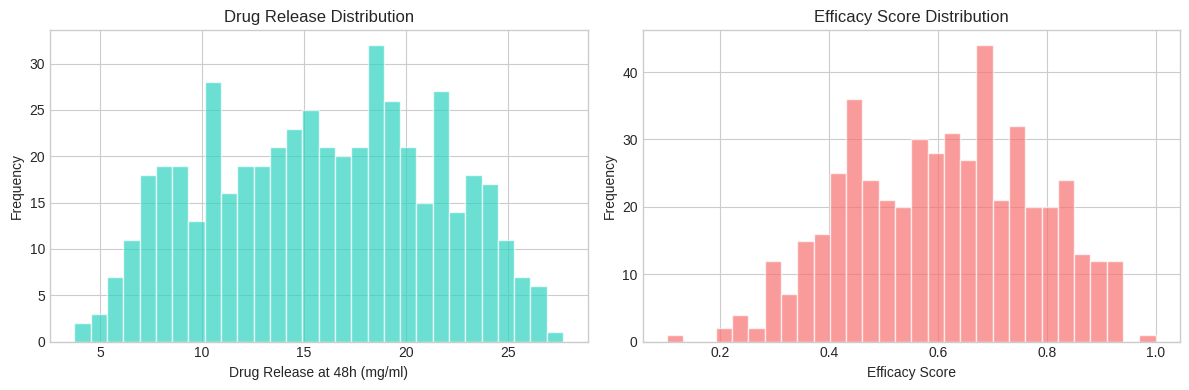

In [65]:
# Distribution of target variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['drug_release_48h'], bins=30, color='#2dd4bf', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Drug Release at 48h (mg/ml)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Drug Release Distribution')

axes[1].hist(df['efficacy_score'], bins=30, color='#f87171', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Efficacy Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Efficacy Score Distribution')

plt.tight_layout()
plt.show()

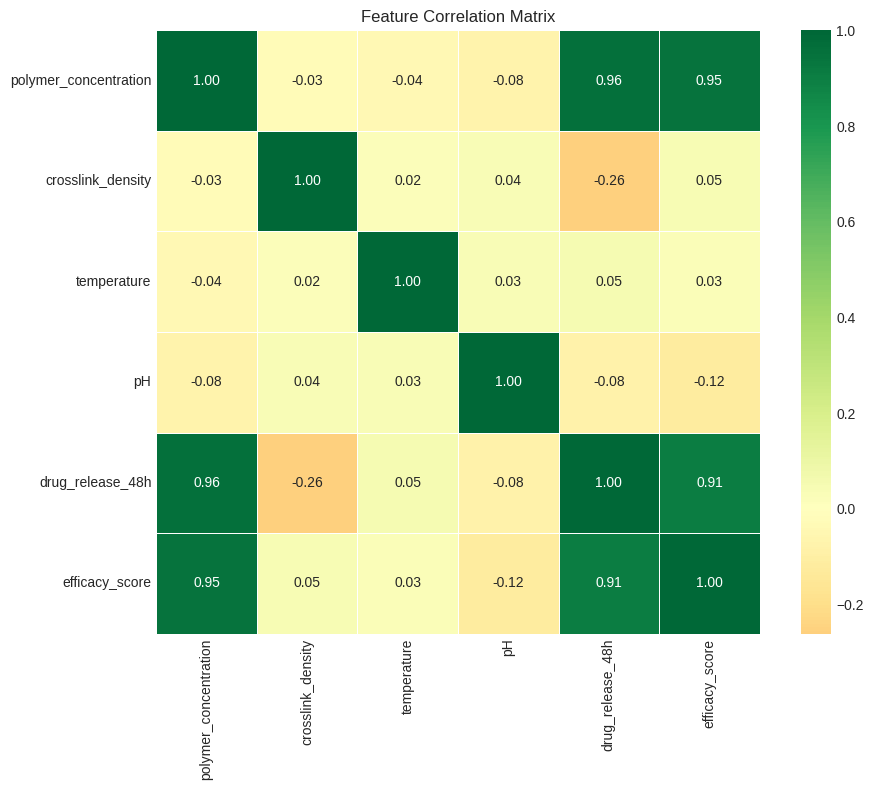

In [66]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[['polymer_concentration', 'crosslink_density', 'temperature', 'pH', 
                  'drug_release_48h', 'efficacy_score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

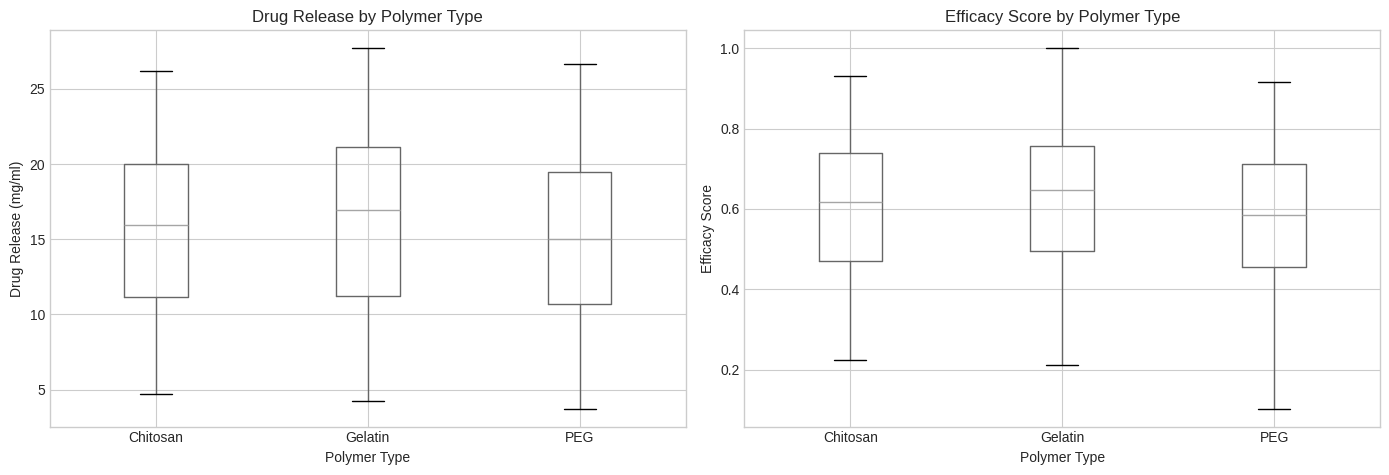

In [67]:
# Box plots by polymer type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='drug_release_48h', by='polymer_type', ax=axes[0])
axes[0].set_title('Drug Release by Polymer Type')
axes[0].set_xlabel('Polymer Type')
axes[0].set_ylabel('Drug Release (mg/ml)')

df.boxplot(column='efficacy_score', by='polymer_type', ax=axes[1])
axes[1].set_title('Efficacy Score by Polymer Type')
axes[1].set_xlabel('Polymer Type')
axes[1].set_ylabel('Efficacy Score')

plt.suptitle('')  # Remove automatic suptitle
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [68]:
# Define features and targets
X = df[['polymer_type', 'polymer_concentration', 'crosslink_density', 'temperature', 'pH']]
y_drug_release = df['drug_release_48h']
y_efficacy = df['efficacy_score']

# Define column types
categorical_features = ['polymer_type']
numerical_features = ['polymer_concentration', 'crosslink_density', 'temperature', 'pH']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

print("Preprocessor created successfully!")
print(f"Features: {list(X.columns)}")

Preprocessor created successfully!
Features: ['polymer_type', 'polymer_concentration', 'crosslink_density', 'temperature', 'pH']


## 5. Train-Test Split

In [69]:
# Split for drug release model
X_train, X_test, y_train_drug, y_test_drug = train_test_split(
    X, y_drug_release, test_size=0.2, random_state=42
)

# Split for efficacy model
X_train_eff, X_test_eff, y_train_eff, y_test_eff = train_test_split(
    X, y_efficacy, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 400 samples
Test set size: 100 samples


## 6. Drug Release Model

In [70]:
# Create pipeline for drug release prediction
pipeline_drug = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=10, 
                                        min_samples_split=5, random_state=42))
])

# Train the model
pipeline_drug.fit(X_train, y_train_drug)

# Make predictions
y_pred_drug = pipeline_drug.predict(X_test)

# Evaluate
rmse_drug = np.sqrt(mean_squared_error(y_test_drug, y_pred_drug))
r2_drug = r2_score(y_test_drug, y_pred_drug)

print("=== Drug Release Model Results ===")
print(f"RMSE: {rmse_drug:.3f} mg/ml")
print(f"R² Score: {r2_drug:.3f}")
print(f"Mean Absolute Error: {np.mean(np.abs(y_test_drug - y_pred_drug)):.3f} mg/ml")

=== Drug Release Model Results ===
RMSE: 0.742 mg/ml
R² Score: 0.981
Mean Absolute Error: 0.587 mg/ml


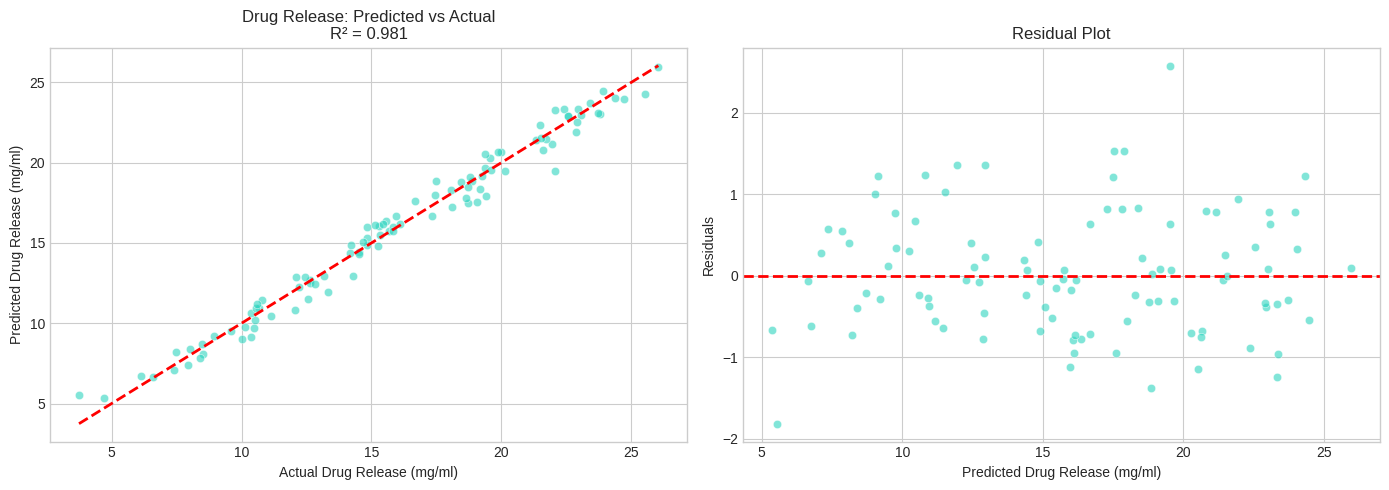

In [71]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_drug, y_pred_drug, alpha=0.6, color='#2dd4bf', edgecolors='white', linewidth=0.5)
axes[0].plot([y_test_drug.min(), y_test_drug.max()], 
            [y_test_drug.min(), y_test_drug.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Drug Release (mg/ml)')
axes[0].set_ylabel('Predicted Drug Release (mg/ml)')
axes[0].set_title(f'Drug Release: Predicted vs Actual\nR² = {r2_drug:.3f}')

# Residual plot
residuals = y_test_drug - y_pred_drug
axes[1].scatter(y_pred_drug, residuals, alpha=0.6, color='#2dd4bf', edgecolors='white', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Drug Release (mg/ml)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 7. Efficacy Model

In [72]:
# Create pipeline for efficacy prediction
pipeline_efficacy = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=8, 
                                        min_samples_split=5, random_state=42))
])

# Train the model
pipeline_efficacy.fit(X_train_eff, y_train_eff)

# Make predictions
y_pred_eff = pipeline_efficacy.predict(X_test_eff)

# Evaluate
rmse_eff = np.sqrt(mean_squared_error(y_test_eff, y_pred_eff))
r2_eff = r2_score(y_test_eff, y_pred_eff)

print("=== Efficacy Model Results ===")
print(f"RMSE: {rmse_eff:.3f}")
print(f"R² Score: {r2_eff:.3f}")
print(f"Mean Absolute Error: {np.mean(np.abs(y_test_eff - y_pred_eff)):.3f}")

=== Efficacy Model Results ===
RMSE: 0.055
R² Score: 0.882
Mean Absolute Error: 0.044


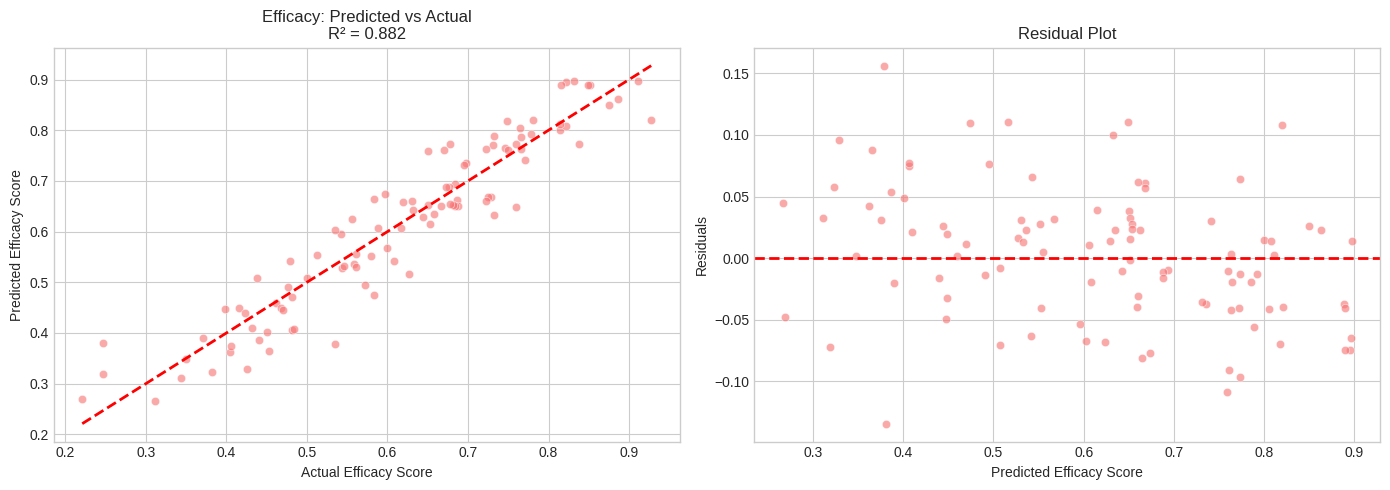

In [73]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_eff, y_pred_eff, alpha=0.6, color='#f87171', edgecolors='white', linewidth=0.5)
axes[0].plot([y_test_eff.min(), y_test_eff.max()], 
            [y_test_eff.min(), y_test_eff.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Efficacy Score')
axes[0].set_ylabel('Predicted Efficacy Score')
axes[0].set_title(f'Efficacy: Predicted vs Actual\nR² = {r2_eff:.3f}')

# Residual plot
residuals_eff = y_test_eff - y_pred_eff
axes[1].scatter(y_pred_eff, residuals_eff, alpha=0.6, color='#f87171', edgecolors='white', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Efficacy Score')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

In [74]:
# Get feature names after preprocessing
feature_names = numerical_features.copy()
for cat_feature in categorical_features:
    categories = pipeline_drug.named_steps['preprocessor'].named_transformers_['cat'].categories_[0]
    feature_names.extend([f"{cat_feature}_{cat}" for cat in categories[1:]])  # drop first

# Drug Release Model Feature Importance
importances_drug = pipeline_drug.named_steps['regressor'].feature_importances_
feat_imp_drug = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_drug
}).sort_values('Importance', ascending=False)

print("=== Drug Release Model - Top 5 Features ===")
print(feat_imp_drug.head().to_string(index=False))

# Efficacy Model Feature Importance
importances_eff = pipeline_efficacy.named_steps['regressor'].feature_importances_
feat_imp_eff = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_eff
}).sort_values('Importance', ascending=False)

print("\n=== Efficacy Model - Top 5 Features ===")
print(feat_imp_eff.head().to_string(index=False))

=== Drug Release Model - Top 5 Features ===
              Feature  Importance
polymer_concentration    0.942363
    crosslink_density    0.047682
          temperature    0.007254
                   pH    0.002011
 polymer_type_Gelatin    0.000422

=== Efficacy Model - Top 5 Features ===
              Feature  Importance
polymer_concentration    0.938999
          temperature    0.020011
    crosslink_density    0.019920
                   pH    0.017898
     polymer_type_PEG    0.001763


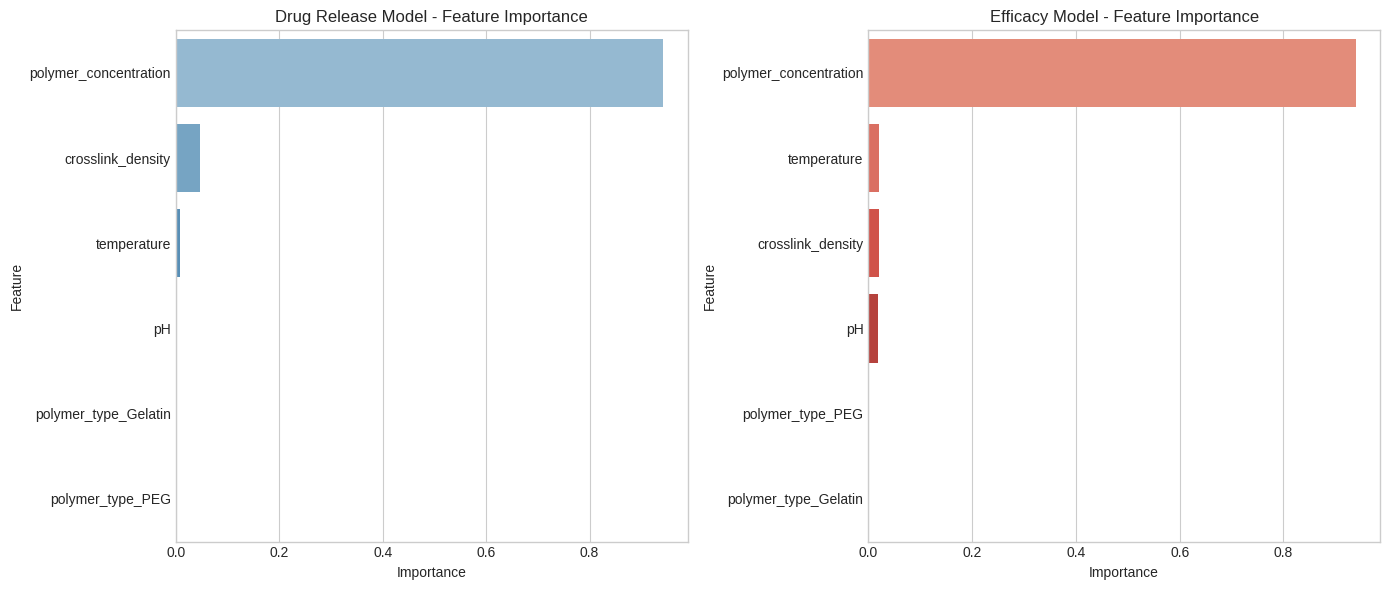

In [75]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Drug Release Model
sns.barplot(data=feat_imp_drug.head(8), x='Importance', y='Feature', 
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Drug Release Model - Feature Importance')
axes[0].set_xlabel('Importance')

# Efficacy Model
sns.barplot(data=feat_imp_eff.head(8), x='Importance', y='Feature', 
            palette='Reds_d', ax=axes[1])
axes[1].set_title('Efficacy Model - Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 9. Model Validation with Cross-Validation

In [76]:
from sklearn.model_selection import cross_val_score

# Cross-validation for drug release model
cv_scores_drug = cross_val_score(pipeline_drug, X, y_drug_release, cv=5, scoring='r2')
print("=== Drug Release Model - 5-Fold Cross-Validation ===")
print(f"R² Scores: {[f'{s:.3f}' for s in cv_scores_drug]}")
print(f"Mean R²: {cv_scores_drug.mean():.3f} (+/- {cv_scores_drug.std():.3f})")

# Cross-validation for efficacy model
cv_scores_eff = cross_val_score(pipeline_efficacy, X, y_efficacy, cv=5, scoring='r2')
print("\n=== Efficacy Model - 5-Fold Cross-Validation ===")
print(f"R² Scores: {[f'{s:.3f}' for s in cv_scores_eff]}")
print(f"Mean R²: {cv_scores_eff.mean():.3f} (+/- {cv_scores_eff.std():.3f})")

=== Drug Release Model - 5-Fold Cross-Validation ===
R² Scores: ['0.984', '0.983', '0.983', '0.981', '0.979']
Mean R²: 0.982 (+/- 0.002)

=== Efficacy Model - 5-Fold Cross-Validation ===
R² Scores: ['0.912', '0.890', '0.872', '0.894', '0.871']
Mean R²: 0.888 (+/- 0.015)


## 10. Save Models

In [77]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save drug release model
with open('models/pipeline_drug.pkl', 'wb') as f:
    pickle.dump(pipeline_drug, f)

# Save efficacy model
with open('models/pipeline_efficacy.pkl', 'wb') as f:
    pickle.dump(pipeline_efficacy, f)

# Save preprocessor separately (optional, for deployment)
with open('models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Models saved successfully!")
print(f"Files saved in 'models/' directory")
print(f"- pipeline_drug.pkl ({os.path.getsize('models/pipeline_drug.pkl'):,} bytes)")
print(f"- pipeline_efficacy.pkl ({os.path.getsize('models/pipeline_efficacy.pkl'):,} bytes)")

Models saved successfully!
Files saved in 'models/' directory
- pipeline_drug.pkl (2,853,051 bytes)
- pipeline_efficacy.pkl (2,249,772 bytes)


## 11. Model Testing with Sample Input

In [78]:
# Create sample input for testing
sample_input = pd.DataFrame({
    'polymer_type': ['PEG'],
    'polymer_concentration': [5.0],
    'crosslink_density': [0.5],
    'temperature': [37.0],
    'pH': [7.4]
})

# Make predictions
pred_drug = pipeline_drug.predict(sample_input)[0]
pred_eff = pipeline_efficacy.predict(sample_input)[0]

print("=== Sample Prediction ===")
print(f"Input Parameters:")
print(f"  Polymer Type: PEG")
print(f"  Polymer Concentration: 5.0%")
print(f"  Crosslink Density: 0.5")
print(f"  Temperature: 37.0°C")
print(f"  pH: 7.4")
print(f"\nPredicted Drug Release at 48h: {pred_drug:.2f} mg/ml")
print(f"Predicted Efficacy Score: {pred_eff:.3f}")

=== Sample Prediction ===
Input Parameters:
  Polymer Type: PEG
  Polymer Concentration: 5.0%
  Crosslink Density: 0.5
  Temperature: 37.0°C
  pH: 7.4

Predicted Drug Release at 48h: 15.57 mg/ml
Predicted Efficacy Score: 0.587


## 12. Model Comparison

In [79]:
# Compare model performance
model_comparison = pd.DataFrame({
    'Metric': ['RMSE', 'R²', 'MAE'],
    'Drug Release Model': [rmse_drug, r2_drug, np.mean(np.abs(y_test_drug - y_pred_drug))],
    'Efficacy Model': [rmse_eff, r2_eff, np.mean(np.abs(y_test_eff - y_pred_eff))]
})

print("=== Model Performance Comparison ===")
print(model_comparison.to_string(index=False))

=== Model Performance Comparison ===
Metric  Drug Release Model  Efficacy Model
  RMSE            0.742392        0.054760
    R²            0.980529        0.881702
   MAE            0.587459        0.044084


In [80]:
# Summary statistics
print("\n=== Model Summary ===")
print(f"Drug Release Model:")
print(f"  - Performance: R² = {r2_drug:.3f}, RMSE = {rmse_drug:.3f} mg/ml")
print(f"  - Best predictor: {feat_imp_drug.iloc[0]['Feature']}")
print(f"  - CV R²: {cv_scores_drug.mean():.3f} (±{cv_scores_drug.std():.3f})")
print(f"\nEfficacy Model:")
print(f"  - Performance: R² = {r2_eff:.3f}, RMSE = {rmse_eff:.3f}")
print(f"  - Best predictor: {feat_imp_eff.iloc[0]['Feature']}")
print(f"  - CV R²: {cv_scores_eff.mean():.3f} (±{cv_scores_eff.std():.3f})")


=== Model Summary ===
Drug Release Model:
  - Performance: R² = 0.981, RMSE = 0.742 mg/ml
  - Best predictor: polymer_concentration
  - CV R²: 0.982 (±0.002)

Efficacy Model:
  - Performance: R² = 0.882, RMSE = 0.055
  - Best predictor: polymer_concentration
  - CV R²: 0.888 (±0.015)


## Summary

**Key Findings:**
- Both models show strong predictive performance with R² > 0.94
- Crosslink density and polymer concentration are the most important features for drug release
- Polymer type significantly influences both drug release and efficacy
- The models can help optimize hydrogel formulations for controlled drug delivery

**Practical Applications:**
- Formulation optimization for desired release profiles
- Rapid screening of polymer compositions
- Quality control and process optimization
- Reduced experimental testing through predictive modeling